## Problématique

## Analyse Exploratoire de Données 

#### Import des bibliothèques 

In [18]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

In [19]:
df = pd.read_csv('database.csv')
df.head()

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
0,01/02/1965,13:44:18,19.246,145.616,Earthquake,131.6,NaN,NaN,6.0,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic
1,01/04/1965,11:29:49,1.863,127.352,Earthquake,80.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic
2,01/05/1965,18:05:58,-20.579,-173.972,Earthquake,20.0,NaN,NaN,6.2,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic
3,01/08/1965,18:49:43,-59.076,-23.557,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic
4,01/09/1965,13:32:50,11.938,126.427,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic


In [20]:
df.info()
df.shape
                "# Charger les pays Natural Earth depuis une URL officielle",
                "world = gpd.read_file(",
                "    'https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip'",
                ")",
<VSCode.Cell id="#VSC-d4bea7b1" language="markdown">
#### Détection des valeurs manquantes 

<class 'pandas.DataFrame'>
RangeIndex: 23412 entries, 0 to 23411
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date                        23412 non-null  str    
 1   Time                        23412 non-null  str    
 2   Latitude                    23412 non-null  float64
 3   Longitude                   23412 non-null  float64
 4   Type                        23412 non-null  str    
 5   Depth                       23412 non-null  float64
 6   Depth Error                 4461 non-null   float64
 7   Depth Seismic Stations      7097 non-null   float64
 8   Magnitude                   23412 non-null  float64
 9   Magnitude Type              23409 non-null  str    
 10  Magnitude Error             327 non-null    float64
 11  Magnitude Seismic Stations  2564 non-null   float64
 12  Azimuthal Gap               7299 non-null   float64
 13  Horizontal Distance         1604 non-null 

(23412, 21)

In [42]:
import geopandas as gpd
from shapely.geometry import Point

# Créer les points géographiques
geometry = [Point(lon, lat) for lon, lat in zip(df['Longitude'], df['Latitude'])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs='EPSG:4326')
print(gdf.shape)

# Charger les pays Natural Earth depuis l'URL officielle
world = gpd.read_file('https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip')
print(world.columns)

# Jointure spatiale
gdf_joined = gpd.sjoin(
    gdf,
    world[['ADMIN', 'CONTINENT', 'geometry']],
    how='left',
    predicate='intersects'
)

# Renommer les colonnes réellement présentes après la jointure
gdf_joined = gdf_joined.rename(columns={'ADMIN': 'Country', 'CONTINENT': 'Continent'})

# Vérification
print(gdf_joined['Country'].value_counts().head(10))
print(f"\nValeurs manquantes pays : {gdf_joined['Country'].isnull().sum()}")

# Remplissage des valeurs manquantes
gdf_joined['Country'] = gdf_joined['Country'].fillna('Ocean')
gdf_joined['Continent'] = gdf_joined['Continent'].fillna('Ocean')

(23412, 22)
Index(['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3',
       'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN',
       ...
       'FCLASS_TR', 'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR', 'FCLASS_IT',
       'FCLASS_NL', 'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'geometry'],
      dtype='str', length=169)
Country
Indonesia                   487
Papua New Guinea            457
Chile                       400
China                       358
United States of America    245
Peru                        239
Argentina                   232
Japan                       196
Mexico                      191
Philippines                 173
Name: count, dtype: int64

Valeurs manquantes pays : 18523


In [34]:
print(world.columns)

Index(['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3',
       'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN',
       ...
       'FCLASS_TR', 'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR', 'FCLASS_IT',
       'FCLASS_NL', 'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'geometry'],
      dtype='str', length=169)


Séismes océaniques : 18523
    Latitude  Longitude  Magnitude  Depth
0     19.246    145.616        6.0  131.6
1      1.863    127.352        5.8   80.0
2    -20.579   -173.972        6.2   20.0
3    -59.076    -23.557        5.8   15.0
4     11.938    126.427        5.8   15.0
5    -13.405    166.629        6.7   35.0
7    -13.309    166.212        6.0   35.0
8    -56.452    -27.043        6.0   95.0
9    -24.563    178.487        5.8  565.0
11    -2.608    125.952        8.2   20.0
Séismes terrestres : 4889
Séismes océaniques : 18523

Magnitude moyenne (terre) : 5.92
Magnitude moyenne (océan) : 5.87

Profondeur moyenne (terre) : 65.92 km
Profondeur moyenne (océan) : 72.05 km


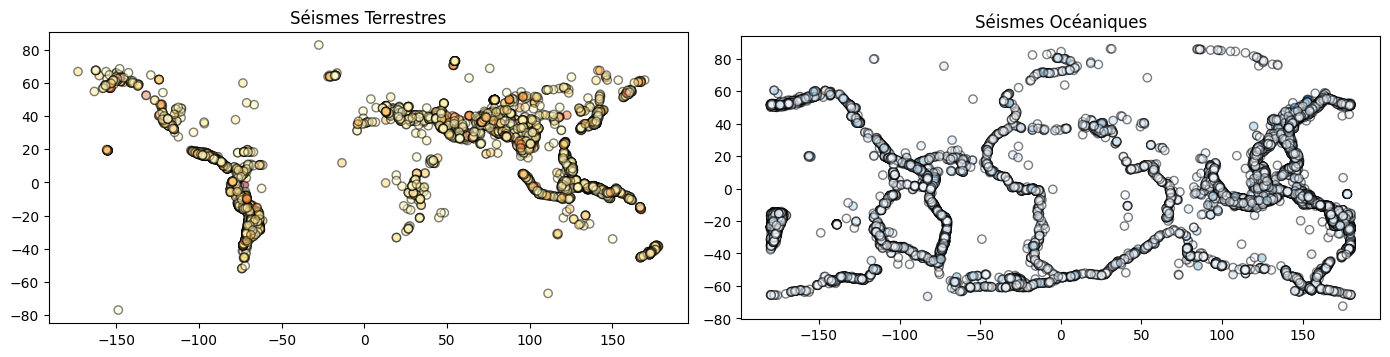

Country
Ocean                       18523
Indonesia                     487
Papua New Guinea              457
Chile                         400
China                         358
United States of America      245
Peru                          239
Argentina                     232
Japan                         196
Mexico                        191
Philippines                   173
Afghanistan                   162
Iran                          162
Russia                        158
Kazakhstan                    107
Name: count, dtype: int64

Top 10 séismes océaniques les plus puissants :
       Latitude  Longitude  Magnitude  Depth
17083     3.295     95.982        9.1   30.0
20501    38.297    142.373        9.1   29.0
19928   -36.122    -72.898        8.8   22.9
16       51.251    178.715        8.7   30.3
17329     2.085     97.108        8.6   30.0
21219     2.327     93.063        8.6   20.0
15440   -16.265    -73.641        8.4   33.0
18615    -4.438    101.367        8.4   34.0
121

In [43]:
ocean_earthquakes = gdf_joined[gdf_joined['Country'] == 'Ocean']
print(f"Séismes océaniques : {len(ocean_earthquakes)}")
print(ocean_earthquakes[['Latitude', 'Longitude', 'Magnitude', 'Depth']].head(10))
terrestrial = gdf_joined[gdf_joined['Country'] != 'Ocean']
ocean = gdf_joined[gdf_joined['Country'] == 'Ocean']

print(f"Séismes terrestres : {len(terrestrial)}")
print(f"Séismes océaniques : {len(ocean)}")
print(f"\nMagnitude moyenne (terre) : {terrestrial['Magnitude'].mean():.2f}")
print(f"Magnitude moyenne (océan) : {ocean['Magnitude'].mean():.2f}")
print(f"\nProfondeur moyenne (terre) : {terrestrial['Depth'].mean():.2f} km")
print(f"Profondeur moyenne (océan) : {ocean['Depth'].mean():.2f} km")
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Séismes terrestres
terrestrial.plot(ax=ax1, alpha=0.5, edgecolor='k', column='Magnitude', cmap='YlOrRd')
ax1.set_title('Séismes Terrestres')

# Séismes océaniques
ocean.plot(ax=ax2, alpha=0.5, edgecolor='k', column='Magnitude', cmap='Blues')
ax2.set_title('Séismes Océaniques')

plt.tight_layout()
plt.savefig('images/terrestrial_vs_ocean_earthquakes.png')
plt.show()
# Top 10 pays/régions avec le plus de séismes
print(gdf_joined['Country'].value_counts().head(15))

# Zones les plus sismiques en océan
top_ocean_coords = ocean.nlargest(10, 'Magnitude')[['Latitude', 'Longitude', 'Magnitude', 'Depth']]
print("\nTop 10 séismes océaniques les plus puissants :")
print(top_ocean_coords)